# HIN survey: map the mechanism, audit the evidence

Standalone survey lab. Complete three TODO functions and their CHECK cells. The full NN graph audit is a separate explicit switch; frozen author evidence is labeled. No local relkit imports or model-training dependencies are required.

In [1]:
# @colab-bootstrap
import os,sys,subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','numpy==2.2.6','pandas==2.3.2','dill==0.3.8'])
import json,hashlib,urllib.request
from pathlib import Path
import numpy as np
import importlib.metadata as metadata
print({k:metadata.version(k) for k in ['numpy','pandas','dill']})


{'numpy': '2.5.0', 'pandas': '3.0.3', 'dill': '0.3.8'}


<div class="package-links"><strong>Lesson + lab package</strong><br><a href="https://avistian.github.io/relational/labs/html/0094-hin-survey.html">Read the executed lab</a> · <a href="https://colab.research.google.com/github/Avistian/relational/blob/main/labs/0094-hin-survey.ipynb">Run in Colab</a> · <a href="https://avistian.github.io/relational/labs/0094-hin-survey.ipynb">Download student notebook</a> · <a href="https://avistian.github.io/relational/labs/solutions/0094-hin-survey.ipynb">Teacher solution</a><br><a href="#lab">Go to exercises</a> · <a href="https://avistian.github.io/relational/reference/hin-taxonomy.html">Reference map</a> · <a href="https://avistian.github.io/relational/labs/l094-reproduction.md">Reproduction contract and commands</a></div>



## One tangible win

Build a defensible map of heterogeneous graph methods. Given a method description, identify **what structure it uses, how routes are chosen, what it learns, and what evidence could test it**. This is the organizing lesson between the three heterogeneous encoders and the coming database/recommendation lessons.

Our mission is to establish when relational structure adds predictive value. A taxonomy helps choose a testable hypothesis. It does not establish that more elaborate structure is better.

**Reading route:** first complete the cold questions; then trace the small graph; finally fill the taxonomy and audit a real released graph in the notebook. You can complete the conceptual core in one sitting and return for the data audit.



## Retrieve before reading

**Cold retrieval:** answer the three questions below before reading their model answers.

Write three short answers from memory before opening the model answers:

1. In L091, what chooses a message's weight matrix?
2. In L092, what does the designer choose before attention is learned?
3. In L093, why does adding relative time not guarantee leakage-free prediction?

<details><summary>Check after attempting</summary><p>R-GCN uses the relation type. HAN starts with selected meta-path neighbor graphs. HGT's time representation changes the computation; availability cutoffs and removal of target edges still have to be enforced by the data pipeline.</p></details>

<!-- depth-walkthrough:start -->


## The big picture · classify assumptions before comparing results

<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · 094 / A MAP OF DESIGN CHOICES</p><p><strong>Bring forward:</strong> R-GCN, HAN and HGT made different choices about transformations and routes. <strong>Follow:</strong> schema → supplied structure → learned representation → prediction task → evidence contract. <strong>Carry forward:</strong> the bipartite and database lessons make the input assumptions concrete before the later controlled comparison.</p><p><a href="https://avistian.github.io/relational/lessons/0091-r-gcn.html">L091: relations</a> · <a href="https://avistian.github.io/relational/lessons/0092-meta-paths.html">L092: paths</a> · <a href="https://avistian.github.io/relational/lessons/0093-hgt.html">L093: attention</a> · <a href="https://avistian.github.io/relational/lessons/0060-broad-model-comparison.html">L060: comparison protocol</a> · <a href="https://avistian.github.io/relational/reference/0091-0100-model-map.html">Sequence map</a></p></div>

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Scrollable architecture: A method map · ask four independent questions">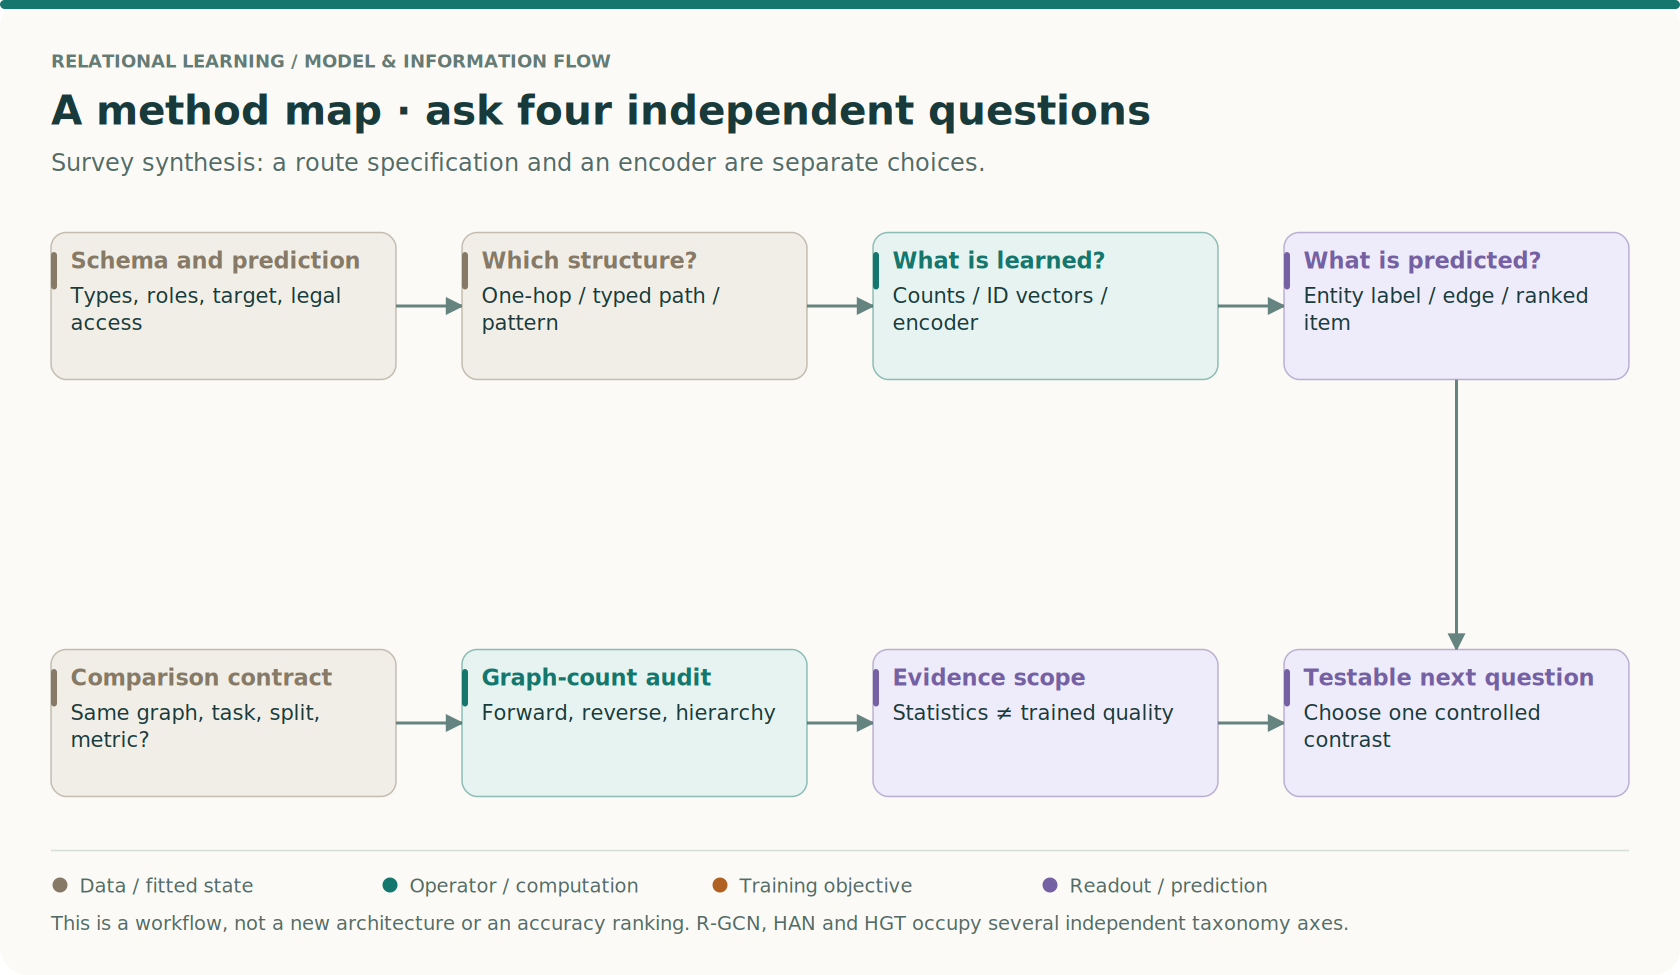</div><figcaption>Survey synthesis: a route specification and an encoder are separate choices. This is a workflow, not a new architecture or an accuracy ranking. R-GCN, HAN and HGT occupy several independent taxonomy axes.</figcaption></figure>

### Use the survey to generate a hypothesis

The primary survey is **Dong, Hu, Wang, Sun and Tang (2020)**, identified precisely in the reading contract below. Read its schema vocabulary before its representation families. A family label should help you predict a behavior: what inputs are required, which distinctions survive, and what happens to an unseen entity. It cannot rank models on its own.

Try the same question for three methods: “What must I provide to represent a new paper?” A node-ID lookup needs a new vector or an explicit inference procedure. An attributed encoder needs suitable features and the required neighbors. A featureless R-GCN that uses identity coordinates still needs a policy for new identities. Calling all three “graph embeddings” conceals this operational difference.

### Locate the lookup model in the same map

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Scrollable architecture: metapath2vec · from typed walks to stored vectors">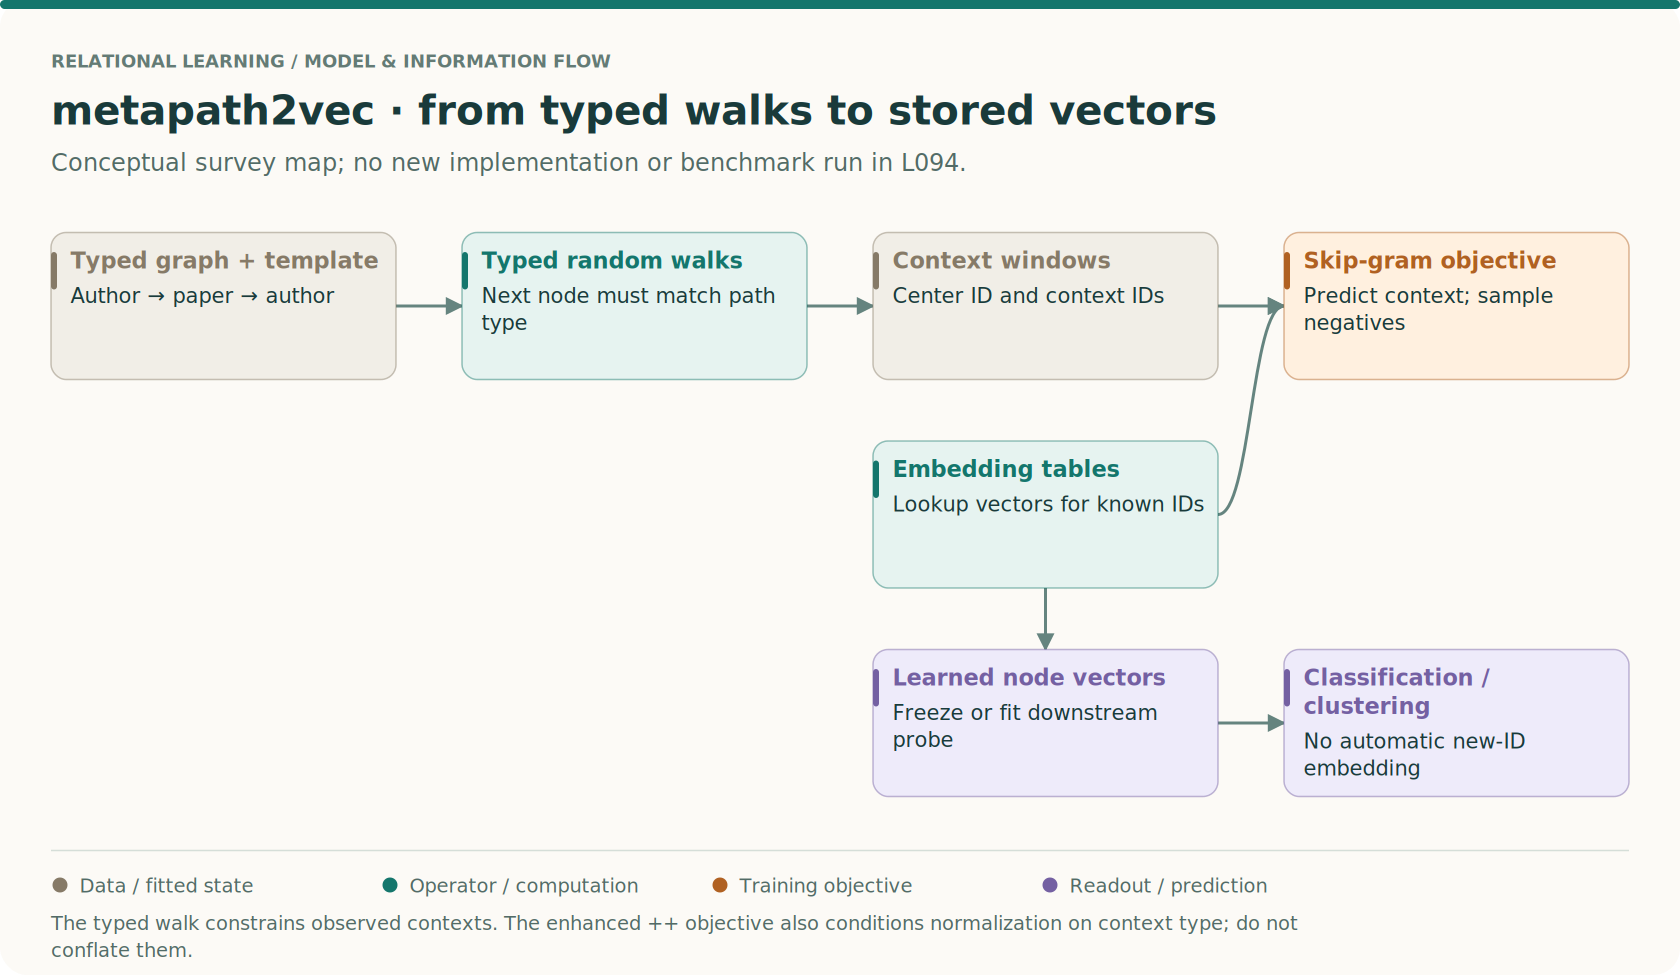</div><figcaption>Conceptual survey map; no new implementation or benchmark run in L094. The typed walk constrains observed contexts. The enhanced ++ objective also conditions normalization on context type; do not conflate them.</figcaption></figure>

The survey mentions metapath2vec, so its architecture deserves a visible handoff too. A designer provides a typed walk template. The walker produces node sequences whose steps respect that template. Context windows turn those sequences into center/context pairs. A skip-gram objective learns lookup vectors that make sampled contexts predictable. The resulting vectors feed a later classifier or clustering procedure. The [authors' project](https://ericdongyx.github.io/metapath2vec/m2v.html) separates walk generation, learning code, saved representations and downstream labels; follow that order when reading it.

This contrasts with HAN even though both use meta-paths. HAN constructs endpoint neighborhoods and computes representations from features with attention. metapath2vec optimizes stored vectors from walk contexts. The enhanced metapath2vec++ objective additionally distinguishes context types; do not transfer a ++ detail silently to the base method. This is a conceptual source map, not an added implementation or fresh reproduction lane.

### A concrete classification exercise

Consider a hypothetical method: choose PAP and PSP, calculate binary endpoint graphs, compute one mean keyword vector per route, concatenate the results, and fit logistic regression. Its route policy is hand-specified; its neighborhood aggregation is fixed; its classifier is learned; its inputs include attributes. Changing only the classifier to a neural head does not make route selection learned. Changing the endpoint graphs into walk counts changes the representation even if the classifier stays identical.

Now replace the mean with a learned GAT operation and add semantic fusion. You can explain why the result resembles HAN by identifying changed operations, rather than by spotting the word “attention.” That vocabulary will let you specify an ablation in L099 precisely.

### Count what the graph actually stores

Suppose a release stores 100 forward facts, their 100 reverse entries, and 12 hierarchy entries outside the listed fact families. “100 edges,” “200 directed entries,” and “212 stored entries” can all describe different legitimate counting conventions. None establishes that two releases contain the same facts. Match the convention, then inspect identities and provenance. The complete NN audit below applies this reasoning to actual released data without repairing a mismatch merely to reach a printed total.

<details><summary>Try first: are “meta-path method” and “GNN” mutually exclusive categories?</summary><p>No. One names supplied route structure and the other names a representation mechanism. HAN belongs to both descriptions. Use independent axes for route selection, learned object, attributes, supervision and prediction target.</p></details>

**Forward connection.** L095 preserves user–item identities that a same-type projection can discard. L096 preserves database roles and event multiplicity. Those are representation decisions made before fitting any encoder. Write one hypothesis linking a retained distinction to a target, plus one intervention that could falsify it. That is the useful output of the survey; a list of impressive model names is not enough.

<!-- depth-walkthrough:end -->



## 1 · Repair the reading contract

The roadmap called this “Sun & Han 2020,” without an identifiable title. This package uses **Dong, Hu, Wang, Sun and Tang (2020), Heterogeneous Network Representation Learning**. Read §1 for schema vocabulary, §3.1–3.2 for the two representation families, and §4 for open questions and OAG statistics. Sun and Han's 2012 work is historical context, not the author list of this 2020 paper. [Primary survey](https://web.cs.ucla.edu/~yzsun/papers/2020_IJCAI_HIN_Survey.pdf).

> **Scope check.** This survey does not introduce a new predictive architecture or a table of its own model accuracy. Its concrete numeric target here is **Table 1's complete NN statistics row**. We audit the entire released NN graph and the arithmetic of all three printed rows. Retraining the preceding models belongs to their named experiment tracks, linked below. A statistics audit is not model-result reproduction.



## 2 · Start with the schema, then choose a question

> **In plain terms.** The schema tells you which kinds of things can connect. A route tells you what relationship you want a sequence of connections to express.

A **heterogeneous information network (HIN)** is a graph whose nodes or relations have multiple types. A node is one entity instance, such as Ada or paper P0. A node type is a category, such as author or paper. An edge relation gives the connection a meaning, such as “writes.” The **schema** is the graph of these types and permitted relations. A **meta-relation** is a source type, relation, target type triple: `(author, writes, paper)`.

The **meta-path** `author → paper → author` is a schema-level sequence. Ada → P1 → Bo is one concrete path instance. The reversed “written by” link must actually be available in the representation; a directed graph does not imply it automatically. These distinctions follow the survey's §1 definitions. [Survey §1](https://web.cs.ucla.edu/~yzsun/papers/2020_IJCAI_HIN_Survey.pdf).

**Worked example.** Four authors write four papers. Ada writes P0 and P1; Bo writes P1 and P2; Cy writes P3; Dee has no papers. P0 and P3 appear at venue V0, while P1 and P2 appear at V1.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">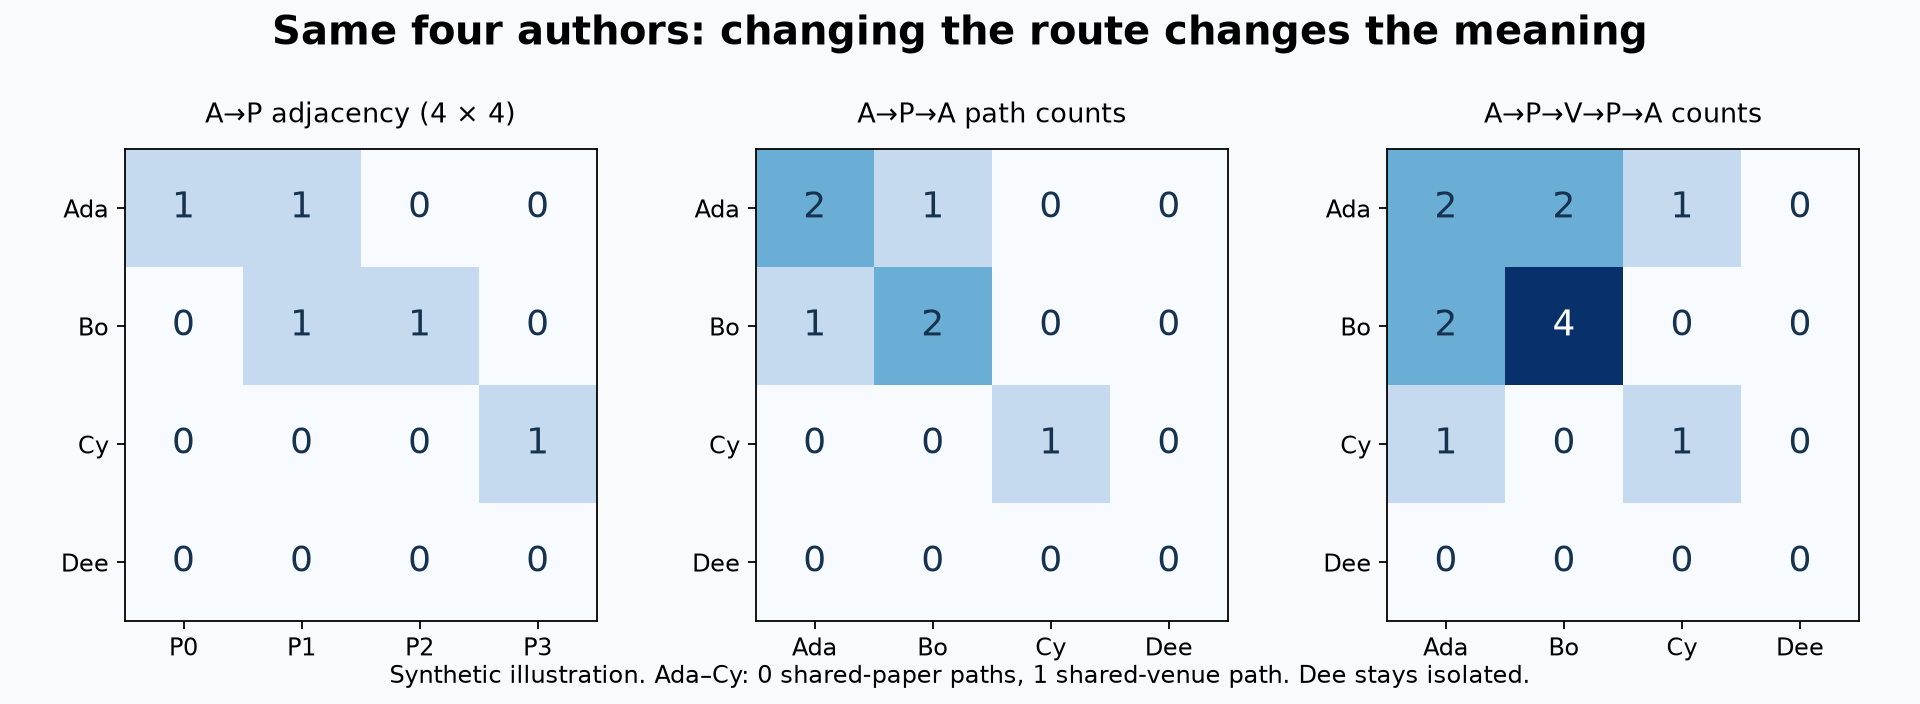</div><figcaption>Synthetic path-count trace with four authors. The same IDs yield different pair connectivity under different routes.</figcaption></figure>

**Step 1: store a relation.** Let `A_AP` be a 4 × 4 matrix: its author row and paper column contain 1 when that authorship exists, otherwise 0. Its transpose `A_PA` reverses that relation.

**Step 2: compose relations.** Matrix multiplication `A_AP @ A_PA` sums over intermediate papers. Entry `(Ada, Bo)` is 1 because they share P1. Entry `(Ada, Ada)` is 2 because Ada has two papers. The diagonal is not automatically an error or a self-loop added by a neural layer; it counts actual returning walks.

**Step 3: change the meaning.** Let `A_PV` have four paper rows and two venue columns. The product `A_AP @ A_PV @ A_PV.T @ A_AP.T` counts shared-venue walks. Ada–Cy changes from 0 to 1. They have no common paper, but both have a paper at V0. Ada–Bo changes from 1 to 2 because two paper-pair combinations pass through V1.

**Step 4: distinguish counts from reachability.** Replacing every positive entry by 1 asks whether a route exists. Keeping the integer asks how many instances exist. Those are different input features. A sparse implementation must preserve the chosen meaning; building these dense products on OAG would be impractical.

### A meta-graph is not simply a longer path

A **meta-graph** is a typed structural pattern that can branch and combine constraints. Here is one explicit teaching example: require both a shared-paper route and a shared-venue route between the same two authors. Define its Boolean result as `(paper_count > 0) AND (venue_count > 0)`. Ada–Cy fails this conjunction despite their shared venue. This example is a chosen pattern semantics; it is not a universal formula for every meta-graph method.

**Portable intervention:** use the route-matrix cells below to remove Bo–P1; predict Ada–Bo counts first.

**Predict, intervene, explain.** Remove Bo's link to P1. Ada–Bo shared-paper count becomes 0; the shared-venue count becomes 1 because Bo still has P2 at V1. Dee's row remains zero. Explain why changing the route can create connectivity without adding an authorship edge.



## 3 · Use independent classification axes

**Commit first:** can HAN belong to both the explicit-meta-path and GNN categories? Explain before reading the map.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">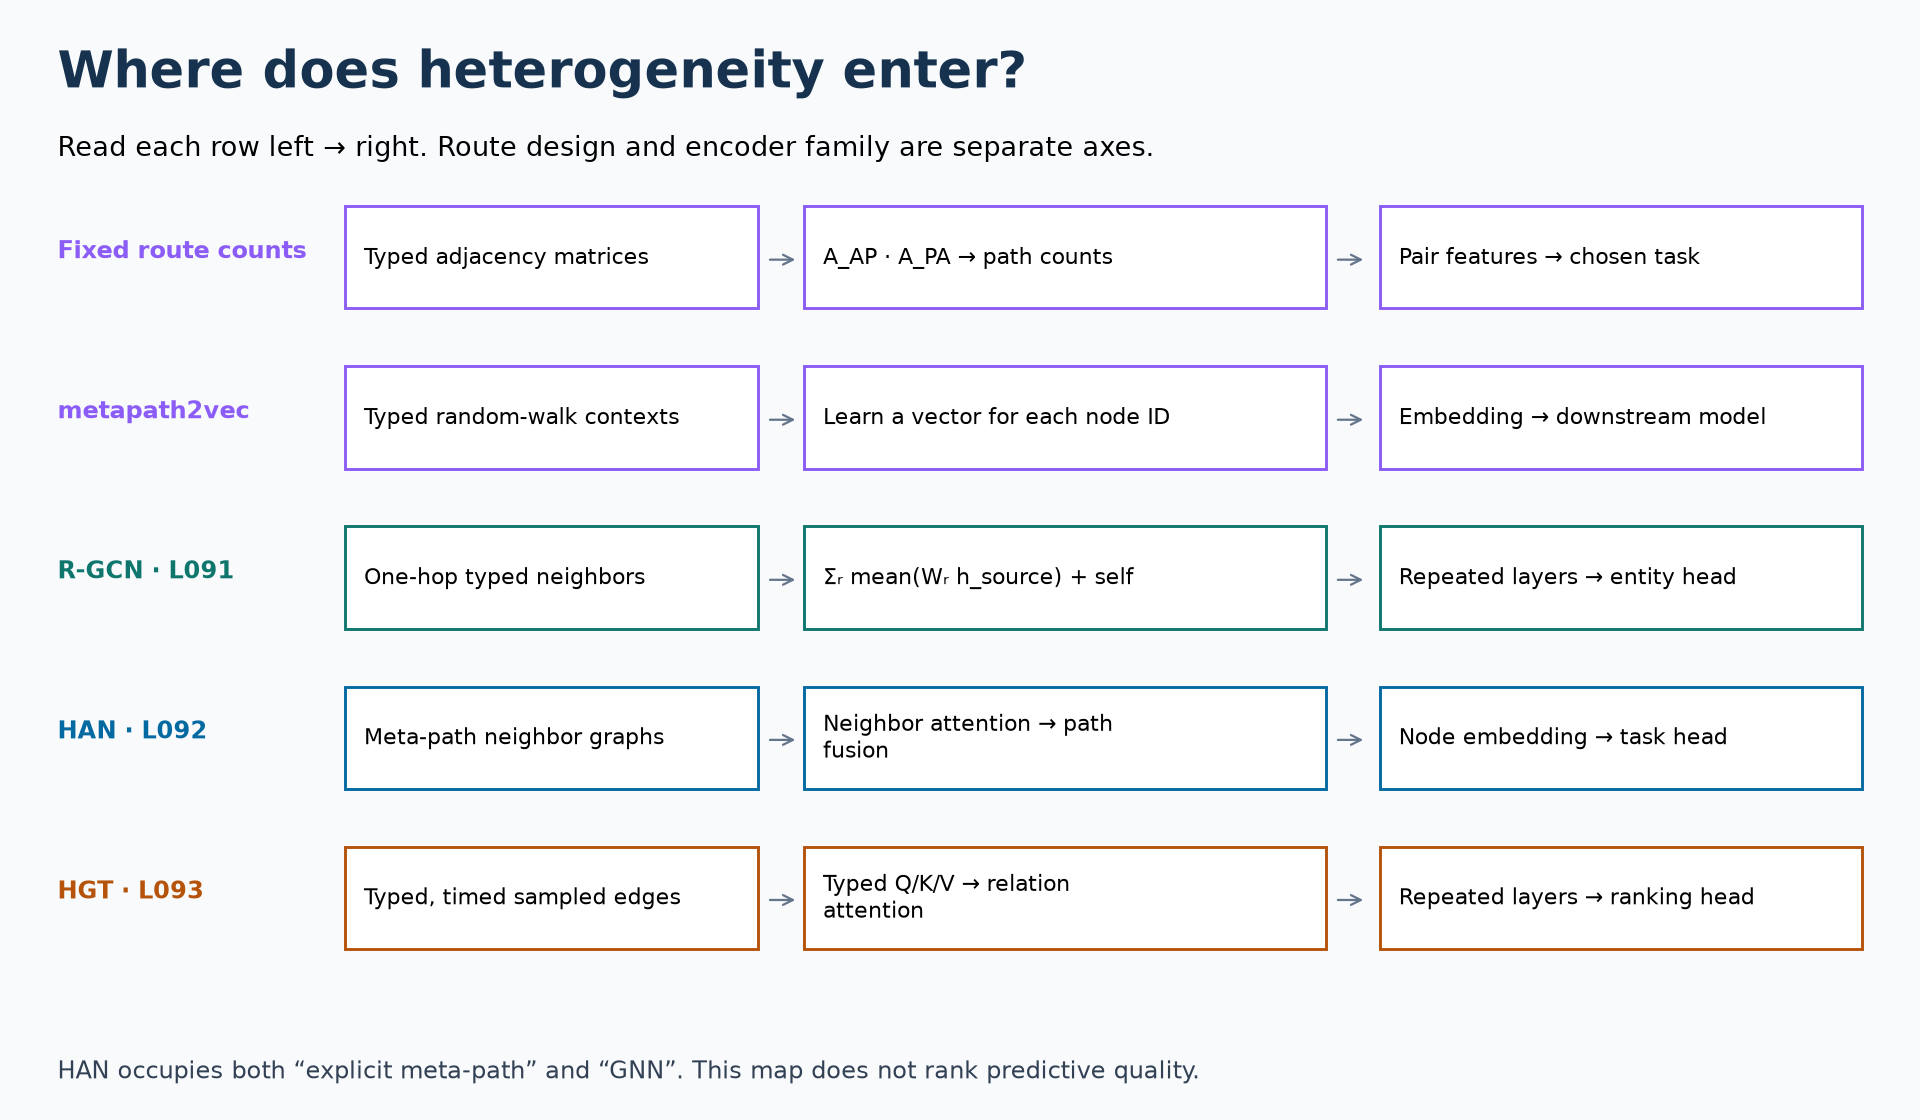</div><figcaption>Encoder and route are separate axes; follow each input through its mechanism to the task handoff.</figcaption></figure>

A useful taxonomy should survive a method that belongs to two categories. “Meta-path” describes route construction; “GNN” describes a learned representation mechanism. They are not competing labels.

| Method | Structure or route supplied | Learned object | Prediction handoff |
|---|---|---|---|
| Fixed route counts | Explicit typed path | Nothing in the counting operator | Counts become task features |
| metapath2vec | Typed walk template and sampled contexts | One embedding vector per node ID | Embeddings feed a downstream task |
| R-GCN · L091 | One-hop relation-labeled edges | Relation transforms, optionally shared bases | Repeated updates feed a task head |
| HAN · L092 | Chosen meta-path neighbor graphs | Neighbor attention and semantic fusion | Fused node representations feed a task head |
| HGT · L093 | Typed edges and relative time contexts | Node-type projections and relation attention/message transforms | Repeated updates feed a task head |

**Read the map’s symbols.** In R-GCN, `h_source` is a source-node vector and `Wᵣ` is the learned linear map for relation `r`; the sum combines relation-specific neighbor means. In HGT, a query (Q) represents what the receiver attends to, a key (K) represents how a source matches that query, and a value (V) is the payload to aggregate. A task head converts the resulting representation into predictions.

**Supervision is another axis.** A supervised objective uses task labels; an unsupervised objective uses another signal, such as node co-occurrences. Route choice alone determines neither. Likewise, node attributes are information supplied to an encoder, while learned node-ID vectors are parameters; they are not interchangeable assumptions.

**Lookup versus encoder.** A lookup table stores a learned vector for each known node ID. A message-passing encoder computes a representation from inputs and neighbors using shared parameters. For a newly arriving node, a lookup table needs an extra rule or optimization. An encoder can compute a new representation when the required features, types, and neighbors are available. [metapath2vec, author project](https://ericdongyx.github.io/metapath2vec/m2v.html); [R-GCN paper](https://arxiv.org/abs/1703.06103).

**Do not collapse route design into attention.** In HAN, the designer supplies the possible routes. Learning semantic weights chooses how to combine representations from those routes. It does not make an omitted route appear. In HGT, multiple layers compose one-hop typed updates, but that is not an exhaustive search over every possible relational query. [HAN §4](https://arxiv.org/abs/1903.07293); [HGT §3](https://arxiv.org/abs/2003.01332).

**Induction needs an input contract.** A GNN is not automatically an inductive experiment. If its only input is a learned embedding tied to training IDs, new IDs still require a policy. A transductive experiment may expose all graph nodes during fitting while hiding test labels. An inductive experiment withholds the target nodes or graphs from fitting. For forecasting, the time at which each feature and edge becomes available adds another constraint. See [L083 GraphSAGE](https://avistian.github.io/relational/lessons/0083-graphsage.html) and [L093 HGT](https://avistian.github.io/relational/lessons/0093-hgt.html).

### Bridge the three preceding lessons

R-GCN addresses the loss of relation meaning caused by a shared transform. HAN addresses the need to distinguish selected multi-hop meanings. HGT addresses typed attention and composition with a scalable sampling strategy. These are different design choices, not three rungs on an accuracy ladder. Revisit their full computation maps: [L091](https://avistian.github.io/relational/lessons/0091-r-gcn.html), [L092](https://avistian.github.io/relational/lessons/0092-meta-paths.html), [L093](https://avistian.github.io/relational/lessons/0093-hgt.html).



## 4 · A taxonomy is not a leaderboard

**Worked evidence trap.** AIFB entity-classification accuracy, ACM embedding KNN F1, and CS paper-field ranking NDCG measure different tasks on different graphs. Sorting their numeric values would produce an ordering with no statistical interpretation. Repeated seeds cannot repair that mismatch. Accuracy is the fraction of correct class predictions. F1 combines precision and recall; KNN here is a k-nearest-neighbor classifier applied to embeddings. NDCG scores the ordering of relevant items with a rank discount and normalizes by an ideal ranking. These quantities have different denominators and prediction units.

An **evaluation protocol** specifies what the model could see, how it was chosen, and how predictions are scored. Compare data hashes, target task, split identities, feature access, target-edge removal, selection rule, compute/search budget, metric definition, and aggregation. A missing field is unknown, not agreement.

The notebook's `compare_protocols` returns `INCOMPARABLE` for a known conflict, `NOT_ESTABLISHED` when required information is missing, and `COMPARABLE` only when every required field is recorded and agrees. That last state is eligibility for a controlled comparison. It is not statistical significance, fairness of every implementation detail, or proof of reproduction.

**A fair next experiment.** Choose one graph, one prediction target, fixed availability rules, a declared split, and a validation-only selection budget. Include a simple baseline that tests whether the task is trivial. Train the candidate encoders with comparable opportunities and report paired outcomes. For a broad family claim, repeat across datasets and aggregate at the dataset level, as in [L055](https://avistian.github.io/relational/lessons/0055-tabred-temporal-splits.html) and [L060](https://avistian.github.io/relational/lessons/0060-broad-model-comparison.html).



## 5 · Reproduce the accounting before trusting the benchmark

**Held fixed:** the SHA-256-pinned complete NN archive and a source-visible read-only loader. **Measured:** every node count and every stored typed adjacency. **Varied:** the edge-count convention. There are no sampled nodes, random seeds, train/validation choices, or fitted models in this audit.

The released structure stores both original and `rev_` relations. It also stores field-to-field hierarchy links, which are absent from the table's five listed edge families. The audit counts original entries, verifies their reverse content, and reports both totals. An edge entry represents a source/target pair within one relation map; repeated events overwritten during preprocessing cannot be recovered from it.

| NN statistic | Paper Table 1 | Complete released NN | Status |
|---|---:|---:|---|
| nodes | 66,211 | 66,211 | MATCH |
| edges | 3,638,702 | 845,916 | MISMATCH |
| paper | 18,911 | 18,911 | MATCH |
| author | 32,307 | 32,307 | MATCH |
| field | 9,540 | 9,540 | MATCH |
| venue | 2,008 | 2,008 | MATCH |
| institute | 3,445 | 3,445 | MATCH |
| PA | 48,551 | 48,551 | MATCH |
| PF | 202,281 | 202,281 | MATCH |
| PV | 189,116 | 18,911 | MISMATCH |
| AI | 48,765 | 48,765 | MATCH |
| PP | 1,355,082 | 67,754 | MISMATCH |

The release has **422,958 forward entries**, including **36,696 field-hierarchy entries**. Adding the verified reverse entries gives **845,916**. Its five listed forward edge families sum to **386,262**. These are distinct counting conventions, not alternative model scores.

**Explain the discrepancy before fixing anything.** Matching all node counts is useful evidence, but it does not establish identical edges or features. An apparent printing error, different preprocessing, or another snapshot could explain some gaps. This audit does not identify which explanation is true. Keep the printed targets unchanged and preserve the mismatch.

| Printed row | Sum of five node types − printed node total | Sum of five edge families − printed edge total |
|---|---:|---:|
| NN | 0 | -1,794,907 |
| CS | 15,238 | 0 |
| OAG | 0 | 0 |

The CS node sum differs by 15,238. The NN listed edge sum differs by −1,794,907. These checks expose accounting questions; they do not establish which entry or convention is wrong.

> **Scope check.** The arithmetic check uses all three printed rows; it does not load CS or OAG. Fresh graph coverage is NN only. Historical snapshot identity and full-paper reproduction remain **NOT_ESTABLISHED**; historical comparison is **INCOMPARABLE**. The counting implementation passes when it accurately reports mismatches. It must not turn a mismatch into a successful reproduction label.

### Follow the existing model evidence without silently rerunning it

| Existing artifact | Named target / executed coverage | Evidence boundary |
|---|---|---|
| L091 | AIFB Table 2; 10 complete release-port runs | Historical backend/seed identity INCOMPARABLE |
| L092 | ACM Table 3 KNN; one encoder, 40 KNN evaluations | Repeated probes are not independent encoder runs; original MAT identity unestablished |
| L093 | CS Table 2 paper-field L2; zero completed CS fits | NOT_RUN; NN teaching fits cannot substitute for CS |


These are hash-pinned **prior author-run artifacts**, inspected in this lesson. They are not new training. The complete models and trainers remain visible in their originating notebooks. The [reproduction contract](https://avistian.github.io/relational/labs/l094-reproduction.md) gives their named commands and remaining gaps. A source operator check, a nearby score, an audit pass, and a complete historical reproduction are four different claims.



## 6 · Open questions become testable choices

**Route selection:** would a missing relation path remove necessary information, or merely reduce noise? Compare route interventions while holding prediction examples fixed.

**Multiple meanings:** are “works with” and “publishes at similar venues” useful for the same target? Do not assume one embedding distance should answer both questions.

**Scalability:** can the sampler reach the relationships that the target needs within the available budget? An elegant full-graph formula does not settle this.

**Availability and transfer:** can the same input contract serve a new entity or a new time period? Relative time encoding does not create historical feature snapshots. These operational questions turn the survey's research agenda into experiments relevant to our mission.

<a id="lab"></a>


## 7 · Lab: build and defend the map

The standalone notebook includes the explanation, portable diagrams, visible audit implementation, frozen evidence, and three live tasks. The default portable exercise uses synthetic matrices (Tier C) and recorded author evidence; an explicit full-graph switch runs the real released NN audit (Tier B). The executed teacher solution runs that full graph locally.

1. **TODO — compose a typed route.** Validate type continuity and compute path counts. CHECK tests multiplicity, an isolated author, and an invalid path.
2. **TODO — classify on two axes.** Represent HAN, HGT, R-GCN, and a lookup model without forcing disjoint categories. CHECK distinguishes route choice from encoder type.
3. **TODO — reject unsupported comparisons.** Make missing protocol fields fail closed. CHECK changes a metric while keeping all other fields fixed.

**EXIT artifact:** produce one row per method with route, encoder, learned parameters, supervision/feature assumptions, and source evidence. Add a 150–250 word defense: why HAN has two labels; why your proposed comparison is eligible; and what the NN mismatch prevents you from claiming. Do not submit only a passing notebook.

**Teach back:** write the EXIT defense before checking the reference map.

**Strict mastery status: `PENDING_WRITTEN_DEFENSE`.** Teacher execution prepares material; it is not evidence that you can retrieve or defend it. Tomorrow, redraw the map from memory before reopening it. Ask the agent follow-up questions and paste your EXIT defense for critique.



## What comes next

L095 uses a user–item graph to turn the taxonomy into a bipartite prediction problem. L096 maps database keys to typed graph relations. Carry forward the key distinction: choosing a schema, choosing a route, learning an encoder, and validating a prediction are separate decisions.


## Exercises: visible implementation

PROVIDED functions implement the complete data audit. Your TODO functions are used by the route intervention, taxonomy export and comparison below.

### TODO · compose_path

Validate typed continuity; compute path multiplicities. A relation matrix has source rows and target columns.

In [2]:
def compose_path(relations, path):
    """Multiply source-row/target-column adjacencies; retain path multiplicity."""
    if not path:raise ValueError('A meta-path needs at least one relation')
    out=None
    for i,key in enumerate(path):
        if i and path[i-1][2]!=key[0]:raise ValueError('Adjacent endpoint types disagree')
        matrix=np.asarray(relations[key],dtype=np.int64)
        if matrix.ndim!=2 or np.any(matrix<0):raise ValueError('Expected nonnegative adjacency matrix')
        out=matrix.copy() if out is None else out@matrix
    return out

In [3]:
ap=np.array([[1,1,0],[0,1,1],[0,0,0]])
r={('A','writes','P'):ap,('P','by','A'):ap.T}
np.testing.assert_array_equal(compose_path(r,list(r)),[[2,1,0],[1,2,0],[0,0,0]])
try:
    compose_path(r,[('A','writes','P'),('A','writes','P')])
except ValueError:
    print('PASS: invalid path rejected; counts and isolated row correct')
else:
    raise AssertionError('Type continuity must be checked')

PASS: invalid path rejected; counts and isolated row correct


### TODO · classify_method

Return labels for encoder and route independently. Supported encoder values: lookup, message_passing, fixed. Supported routes: explicit_path, one_hop, branching.

In [4]:
def classify_method(record):
    """Two independent axes, not a mutually exclusive family tree."""
    enc={'lookup':'lookup embedding','message_passing':'GNN','fixed':'fixed structural score'}
    routes={'explicit_path':'explicit meta-path','one_hop':'one-hop composition','branching':'meta-graph'}
    return [enc[record['encoder']],routes[record['route']]]

In [5]:
assert classify_method({'encoder':'message_passing','route':'explicit_path'})==['GNN','explicit meta-path']
assert classify_method({'encoder':'lookup','route':'explicit_path'})==['lookup embedding','explicit meta-path']
assert classify_method({'encoder':'message_passing','route':'one_hop'})==['GNN','one-hop composition']
print('PASS: HAN crosses categories; a shared route does not imply a shared encoder')

PASS: HAN crosses categories; a shared route does not imply a shared encoder


### TODO · compare_protocols

Inspect dataset_hash, task, split_hash, features, target_mask, selection, budget, metric and aggregation. Known conflicts mean INCOMPARABLE; absent/None/empty/UNKNOWN fields mean NOT_ESTABLISHED unless a conflict already proves incomparability. Otherwise COMPARABLE. Return status, differences and optional unknown fields.

In [6]:
def compare_protocols(left,right):
    """Fail closed: unknown fields never prove compatibility, even when equal."""
    keys=['dataset_hash','task','split_hash','features','target_mask','selection','budget','metric','aggregation']
    unknown=[k for k in keys if left.get(k) in (None,'','UNKNOWN') or right.get(k) in (None,'','UNKNOWN')]
    differences=[k for k in keys if k not in unknown and left[k]!=right[k]]
    status='INCOMPARABLE' if differences else ('NOT_ESTABLISHED' if unknown else 'COMPARABLE')
    result={'status':status,'differences':differences}
    if unknown:result['unknown']=unknown
    return result

In [7]:
p={k:'fixed' for k in ['dataset_hash','task','split_hash','features','target_mask','selection','budget','metric','aggregation']}
assert compare_protocols(p,p)=={'status':'COMPARABLE','differences':[]}
assert compare_protocols(p,dict(p,metric='changed'))['status']=='INCOMPARABLE'
assert compare_protocols({}, {})['status']=='NOT_ESTABLISHED'
assert compare_protocols(dict(p,metric=None),dict(p,metric=None))['status']=='NOT_ESTABLISHED'
print('PASS: missing information is not agreement')

PASS: missing information is not agreement


### PROVIDED · table_arithmetic

Check the printed partition under a declared single-direction convention.

In [8]:
def table_arithmetic(row):
    """Check the printed partition under a declared single-direction convention."""
    ns=sum(row[k] for k in ['paper','author','field','venue','institute'])
    es=sum(row[k] for k in ['PA','PF','PV','AI','PP'])
    return {'node_sum':ns,'node_delta':ns-row['nodes'],'edge_sum':es,'edge_delta':es-row['edges']}

### PROVIDED · count_graph

Release maps use target -> source -> relation -> target ID -> source IDs.
Count distinct stored adjacency entries, not timestamp multiplicities.
Do not silently discard FF edges, reverse edges, or unmatched reverse content.

In [9]:
def count_graph(graph):
    """Release maps use target -> source -> relation -> target ID -> source IDs.
    Count distinct stored adjacency entries, not timestamp multiplicities.
    Do not silently discard FF edges, reverse edges, or unmatched reverse content.
    """
    nodes={k:len(v) for k,v in graph.node_feature.items()}
    rows=[];forward=0;stored=0;reverse_ok=True
    columns={k:0 for k in ['PA','PF','PV','AI','PP']}
    pairs={frozenset(['paper','author']):'PA',frozenset(['paper','field']):'PF',frozenset(['paper','venue']):'PV',frozenset(['author','affiliation']):'AI',frozenset(['paper']):'PP'}
    for target,sources in graph.edge_list.items():
        for source,rels in sources.items():
            for relation,adj in rels.items():
                n=sum(len(neighbors) for neighbors in adj.values());stored+=n
                reverse=relation.startswith('rev_')
                rows.append({'source':source,'target':target,'relation':relation,'edges':n,'reverse':reverse})
                if reverse:continue
                forward+=n
                column=pairs.get(frozenset([source,target]))
                if column:columns[column]+=n
                back=graph.edge_list.get(source,{}).get(target,{}).get('rev_'+relation,{})
                if sum(map(len,back.values()))!=n:reverse_ok=False
                for dst,srcs in adj.items():
                    for src,stamp in srcs.items():
                        if dst not in back.get(src,{}) or back[src][dst]!=stamp:reverse_ok=False
    columns.update({'nodes':sum(nodes.values()),'edges':stored,'paper':nodes.get('paper',0),'author':nodes.get('author',0),'field':nodes.get('field',0),'venue':nodes.get('venue',0),'institute':nodes.get('affiliation',0)})
    return {'nodes_by_type':nodes,'relations':rows,'forward_edges':forward,'all_stored_edges':stored,'listed_forward_edges':sum(columns[k] for k in ['PA','PF','PV','AI','PP']),'unlisted_forward_edges':forward-sum(columns[k] for k in ['PA','PF','PV','AI','PP']),'reverse_content_matches':reverse_ok,'table_columns':columns}

### PROVIDED · file_sha256

Streaming SHA-256 identifies exact bytes.

In [10]:
def file_sha256(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for block in iter(lambda:f.read(8*1024*1024),b''):h.update(block)
    return h.hexdigest()

### CHECK · intervention uses your route composer

In [11]:
ap=np.array([[1,1,0,0],[0,1,1,0],[0,0,0,1],[0,0,0,0]])
pv=np.array([[1,0],[0,1],[0,1],[1,0]])
def routes(ap):
    r={('A','writes','P'):ap,('P','by','A'):ap.T,('P','at','V'):pv,('V','hosts','P'):pv.T}
    return compose_path(r,[('A','writes','P'),('P','by','A')]),compose_path(r,[('A','writes','P'),('P','at','V'),('V','hosts','P'),('P','by','A')])
paper,venue=routes(ap);assert (paper[0,1],venue[0,1],paper[0,2],venue[0,2])==(1,2,0,1)
changed=ap.copy();changed[1,1]=0;p2,v2=routes(changed);assert (p2[0,1],v2[0,1])==(0,1)
print('Baseline shared paper:\n',paper,'\nShared venue:\n',venue,'\nAfter removal, Ada–Bo:',p2[0,1],v2[0,1])

Baseline shared paper:
 [[2 1 0 0]
 [1 2 0 0]
 [0 0 1 0]
 [0 0 0 0]] 
Shared venue:
 [[2 2 1 0]
 [2 4 0 0]
 [1 0 1 0]
 [0 0 0 0]] 
After removal, Ada–Bo: 0 1


### PROVIDED · exact published statistics and prior-run records

These are author-reference evidence, not newly trained models. Their byte hashes identify the source files; the notebook stores selected fields for portable inspection; full parsed records remain in the provenance archive.

In [12]:
PAPER_TABLE = json.loads('{"NN": {"nodes": 66211, "edges": 3638702, "paper": 18911, "author": 32307, "field": 9540, "venue": 2008, "institute": 3445, "PA": 48551, "PF": 202281, "PV": 189116, "AI": 48765, "PP": 1355082}, "CS": {"nodes": 11732027, "edges": 107263811, "paper": 5597605, "author": 5985759, "field": 119537, "venue": 27433, "institute": 16931, "PA": 15571614, "PF": 47462559, "PV": 5597606, "AI": 7190480, "PP": 31441552}, "OAG": {"nodes": 178663927, "edges": 2236196802, "paper": 89606257, "author": 88364081, "field": 615228, "venue": 53073, "institute": 25288, "PA": 300853688, "PF": 657049405, "PV": 89606258, "AI": 167449933, "PP": 1021237518}}')
AUTHOR_AUDIT = json.loads('{"status": "FULL_RELEASE_GRAPH_AUDITED", "dataset": "NN", "data_sha256": "7e0e7b997c427af479148f1d9af419878648b0624b4d3f9f1790bc3625cd7e61", "data_bytes": 656262985, "seconds": 0.5700712203979492, "python": "3.12.3", "implementation_sha256": "e0d10b083da71905e52d033607e74cbeef00fb97997dd59319ffa19b736f87d2", "loader_sha256": "7f188e5e8461638345d469f7cb4dccdd72052224e2cc05769741cd3463a82304", "paper_sha256": "6ff12f841635014ed257180cbb0810e8c5988fda1d24cf4d3da9a517d3ecce06", "table_sha256": "0ca97274913709ac8dbd7459d4c7572600ded3a918a488efab6ec76c7b6b4d63", "statistics": {"nodes_by_type": {"paper": 18911, "author": 32307, "venue": 2008, "affiliation": 3445, "field": 9540}, "relations": [{"source": "paper", "target": "venue", "relation": "PV_Conference", "edges": 7990, "reverse": false}, {"source": "paper", "target": "venue", "relation": "PV_Journal", "edges": 8113, "reverse": false}, {"source": "paper", "target": "venue", "relation": "PV_Repository", "edges": 2791, "reverse": false}, {"source": "paper", "target": "venue", "relation": "PV_Patent", "edges": 17, "reverse": false}, {"source": "venue", "target": "paper", "relation": "rev_PV_Conference", "edges": 7990, "reverse": true}, {"source": "venue", "target": "paper", "relation": "rev_PV_Journal", "edges": 8113, "reverse": true}, {"source": "venue", "target": "paper", "relation": "rev_PV_Repository", "edges": 2791, "reverse": true}, {"source": "venue", "target": "paper", "relation": "rev_PV_Patent", "edges": 17, "reverse": true}, {"source": "paper", "target": "paper", "relation": "PP_cite", "edges": 67754, "reverse": false}, {"source": "paper", "target": "paper", "relation": "rev_PP_cite", "edges": 67754, "reverse": true}, {"source": "field", "target": "paper", "relation": "rev_PF_in_L0", "edges": 18911, "reverse": true}, {"source": "field", "target": "paper", "relation": "rev_PF_in_L3", "edges": 32533, "reverse": true}, {"source": "field", "target": "paper", "relation": "rev_PF_in_L1", "edges": 49732, "reverse": true}, {"source": "field", "target": "paper", "relation": "rev_PF_in_L2", "edges": 91964, "reverse": true}, {"source": "field", "target": "paper", "relation": "rev_PF_in_L5", "edges": 1936, "reverse": true}, {"source": "field", "target": "paper", "relation": "rev_PF_in_L4", "edges": 7205, "reverse": true}, {"source": "author", "target": "paper", "relation": "AP_write_last", "edges": 13329, "reverse": false}, {"source": "author", "target": "paper", "relation": "AP_write_other", "edges": 21170, "reverse": false}, {"source": "author", "target": "paper", "relation": "AP_write_first", "edges": 14052, "reverse": false}, {"source": "field", "target": "field", "relation": "FF_in", "edges": 36696, "reverse": false}, {"source": "field", "target": "field", "relation": "rev_FF_in", "edges": 36696, "reverse": true}, {"source": "paper", "target": "field", "relation": "PF_in_L0", "edges": 18911, "reverse": false}, {"source": "paper", "target": "field", "relation": "PF_in_L3", "edges": 32533, "reverse": false}, {"source": "paper", "target": "field", "relation": "PF_in_L1", "edges": 49732, "reverse": false}, {"source": "paper", "target": "field", "relation": "PF_in_L2", "edges": 91964, "reverse": false}, {"source": "paper", "target": "field", "relation": "PF_in_L5", "edges": 1936, "reverse": false}, {"source": "paper", "target": "field", "relation": "PF_in_L4", "edges": 7205, "reverse": false}, {"source": "author", "target": "affiliation", "relation": "in", "edges": 48765, "reverse": false}, {"source": "affiliation", "target": "author", "relation": "rev_in", "edges": 48765, "reverse": true}, {"source": "paper", "target": "author", "relation": "rev_AP_write_last", "edges": 13329, "reverse": true}, {"source": "paper", "target": "author", "relation": "rev_AP_write_other", "edges": 21170, "reverse": true}, {"source": "paper", "target": "author", "relation": "rev_AP_write_first", "edges": 14052, "reverse": true}], "forward_edges": 422958, "all_stored_edges": 845916, "listed_forward_edges": 386262, "unlisted_forward_edges": 36696, "reverse_content_matches": true, "table_columns": {"PA": 48551, "PF": 202281, "PV": 18911, "AI": 48765, "PP": 67754, "nodes": 66211, "edges": 845916, "paper": 18911, "author": 32307, "field": 9540, "venue": 2008, "institute": 3445}}, "comparison": {"nodes": {"paper": 66211, "released": 66211, "delta": 0, "status": "MATCH"}, "edges": {"paper": 3638702, "released": 845916, "delta": -2792786, "status": "MISMATCH"}, "paper": {"paper": 18911, "released": 18911, "delta": 0, "status": "MATCH"}, "author": {"paper": 32307, "released": 32307, "delta": 0, "status": "MATCH"}, "field": {"paper": 9540, "released": 9540, "delta": 0, "status": "MATCH"}, "venue": {"paper": 2008, "released": 2008, "delta": 0, "status": "MATCH"}, "institute": {"paper": 3445, "released": 3445, "delta": 0, "status": "MATCH"}, "PA": {"paper": 48551, "released": 48551, "delta": 0, "status": "MATCH"}, "PF": {"paper": 202281, "released": 202281, "delta": 0, "status": "MATCH"}, "PV": {"paper": 189116, "released": 18911, "delta": -170205, "status": "MISMATCH"}, "AI": {"paper": 48765, "released": 48765, "delta": 0, "status": "MATCH"}, "PP": {"paper": 1355082, "released": 67754, "delta": -1287328, "status": "MISMATCH"}}, "printed_table_arithmetic": {"NN": {"node_sum": 66211, "node_delta": 0, "edge_sum": 1843795, "edge_delta": -1794907}, "CS": {"node_sum": 11747265, "node_delta": 15238, "edge_sum": 107263811, "edge_delta": 0}, "OAG": {"node_sum": 178663927, "node_delta": 0, "edge_sum": 2236196802, "edge_delta": 0}}, "paper_result_parity": "NOT_ESTABLISHED", "historical_comparison": "INCOMPARABLE", "scope": "Every node and stored adjacency of the named release; arithmetic only for other printed rows; no predictive training", "fresh_graph_coverage": ["NN"], "not_run": ["CS", "OAG"]}')
PRIOR_EVIDENCE = json.loads('{"91": {"filename": "_paper_l091_results.json", "sha256": "4ea4ea7232b56b2b2e7ff8b1924515efa4213480d3dce70c7cc2bfb023948357", "record": {"status": "EXECUTED", "historical_exact_parity": "INCOMPARABLE", "source_revision": "4bec1341dd46b72bf482f7ed26c2dca4533577f6", "data_sha256": "11823f0265dbc4928c055303f6dd5520935c3b9f19de402928c921da37482690", "recorded_training_runs": 10}, "scope": "Selected fields; full parsed record is archived in sources/hin-l094/prior-evidence.json"}, "92": {"filename": "_paper_l092_results.json", "sha256": "044e6bf8517916959e9541bcecca784dd72cd2f0680e1a6f2b7b65048f617f0d", "record": {"status": "FULL_RELEASE_SCHEDULE_EXECUTED", "historical_parity": "INCOMPARABLE", "full_paper_parity": "NOT_ESTABLISHED", "training_runs": 1, "knn_per_training_run": 40, "recorded_training_runs": 1}, "scope": "Selected fields; full parsed record is archived in sources/hin-l094/prior-evidence.json"}, "93": {"filename": "_paper_l093_results.json", "sha256": "5b91dd59f19937aaace9a6d67fa777d3cf54678b3fdaa54fbe007177bfab031c", "record": {"status": "NOT_RUN", "historical_parity": "INCOMPARABLE", "full_paper_parity": "NOT_ESTABLISHED", "completed_CS_fits": 0, "planned_CS_fits": 5, "source_revision": "85eaccd482bc1d1af56c2de297b6e3a88b96d5cd"}, "scope": "Selected fields; full parsed record is archived in sources/hin-l094/prior-evidence.json"}}')
MANIFEST = json.loads('{"paper": {"title": "Heterogeneous Network Representation Learning", "authors": "Yuxiao Dong, Ziniu Hu, Kuansan Wang, Yizhou Sun, Jie Tang", "year": 2020, "url": "https://web.cs.ucla.edu/~yzsun/papers/2020_IJCAI_HIN_Survey.pdf", "sha256": "6ff12f841635014ed257180cbb0810e8c5988fda1d24cf4d3da9a517d3ecce06", "target": "Table 1, complete NN row; all three rows arithmetic audit", "table_sha256": "0ca97274913709ac8dbd7459d4c7572600ded3a918a488efab6ec76c7b6b4d63"}, "nn_data": {"filename": "graph_NN.pk", "bytes": 656262985, "sha256": "7e0e7b997c427af479148f1d9af419878648b0624b4d3f9f1790bc3625cd7e61", "url": "https://drive.usercontent.google.com/download?id=1U8rxYcBljfey6t04qrKmtfvdO8x8wJyu&export=download&confirm=t"}, "source_revision": "85eaccd482bc1d1af56c2de297b6e3a88b96d5cd", "source_url": "https://github.com/acbull/pyHGT", "loader_origin_sha256": "679e0d886e03ec96bd3d9b7d29139efdff1dee6837af263bac9aaa4c5c00ff4f", "historical_snapshot_identity": "NOT_ESTABLISHED", "counting": "Distinct adjacency entries; report all stored, forward-only, listed-forward, and unlisted FF separately."}')

In [13]:
for name,row in PAPER_TABLE.items():print(name,table_arithmetic(row))
assert table_arithmetic(PAPER_TABLE['CS'])['node_delta']==15238
assert table_arithmetic(PAPER_TABLE['NN'])['edge_delta']==-1794907
assert PRIOR_EVIDENCE['93']['record']['status']=='NOT_RUN'
assert PRIOR_EVIDENCE['92']['record']['training_runs']==1
print('Prior evidence inspected; fresh training fits in this notebook: 0')

NN {'node_sum': 66211, 'node_delta': 0, 'edge_sum': 1843795, 'edge_delta': -1794907}
CS {'node_sum': 11747265, 'node_delta': 15238, 'edge_sum': 107263811, 'edge_delta': 0}
OAG {'node_sum': 178663927, 'node_delta': 0, 'edge_sum': 2236196802, 'edge_delta': 0}
Prior evidence inspected; fresh training fits in this notebook: 0


### PROVIDED · complete read-only OAG loader

Compatibility code is copied from the audited L093 loader. Only the SHA-256-pinned author archive is loaded. Old defaultdict factories are not executed. This is a read-only port, not proof of historical preprocessing identity.

In [14]:
"""Read-only OAG compatibility loader extracted from L093; see pinned provenance."""
import dill
import pandas as pd

class OAGGraph:
    """Compatibility container for the authors' released dill Graph object."""
    def get_types(self):return list(self.node_feature)
    def get_meta_graph(self):
        return [(t,s,r) for t,sv in self.edge_list.items() for s,rv in sv.items() for r in rv]

def inert_legacy_code(*args):
    # Python3.7 bytecode in old defaultdict factories is not executed.
    return None

def inert_legacy_function(*args):
    # The downloaded graph stores populated maps. Their historical lambda
    # factories are irrelevant to read-only sampling; missing keys must not be used.
    return dict

def legacy_type(name):
    return inert_legacy_code if name=='CodeType' else dill._dill._load_type(name)

class OAGUnpickler(dill.Unpickler):
    def find_class(self,module,name):
        if name=='Graph' and module in ('pyHGT.data','GPT_GNN.data','data'):return OAGGraph
        if module=='pandas.core.indexes.numeric':return pd.Index
        if module in ('data','pyHGT.data','GPT_GNN.data') and name=='__dict__':return {}
        if module=='dill._dill' and name=='_load_type':return legacy_type
        if module=='dill._dill' and name=='_create_function':return inert_legacy_function
        return super().find_class(module,name)

def load_oag(path,expected_sha256):
    """Verify trusted release bytes before deserializing; missing hash fails closed."""
    if not expected_sha256 or file_sha256(path)!=expected_sha256:raise ValueError('OAG data SHA256 mismatch or missing expected hash')
    with open(path,'rb') as f:g=OAGUnpickler(f).load()
    assert 'paper' in g.node_feature and 'field' in g.node_feature
    return g


### Full published-data target · Table 1 NN

Set RUN_FULL_GRAPH=True to audit every entry. The 656 MB download needs sufficient disk/RAM; no GPU is needed. The default keeps downloads explicit. Existing local data can be supplied through L094_DATA_PATH. Result JSON includes every relation count and a comparison with the printed row. CS and OAG are NOT_RUN in this notebook.

In [15]:
RUN_FULL_GRAPH = os.environ.get('L094_RUN_FULL_GRAPH') == '1'
if RUN_FULL_GRAPH:
    path=Path(os.environ.get('L094_DATA_PATH','graph_NN.pk'))
    if not path.exists():
        temporary=path.with_suffix('.part')
        urllib.request.urlretrieve(MANIFEST['nn_data']['url'],temporary)
        assert file_sha256(temporary)==MANIFEST['nn_data']['sha256']
        temporary.replace(path)
    graph=load_oag(path,MANIFEST['nn_data']['sha256'])
    observed=count_graph(graph)
    assert observed==AUTHOR_AUDIT['statistics'], 'Graph content or counting implementation changed'
    assert observed['reverse_content_matches']
    Path('l094-inline-graph.json').write_text(json.dumps(observed,indent=2))
    for key,value in observed['table_columns'].items():
        print(key,'paper:',PAPER_TABLE['NN'][key],'released:',value)
    print('Full released NN audited; historical parity remains NOT_ESTABLISHED')
else:
    print('Fresh full-graph audit NOT_RUN in this kernel; author evidence above is frozen')

PA paper: 48551 released: 48551
PF paper: 202281 released: 202281
PV paper: 189116 released: 18911
AI paper: 48765 released: 48765
PP paper: 1355082 released: 67754
nodes paper: 66211 released: 66211
edges paper: 3638702 released: 845916
paper paper: 18911 released: 18911
author paper: 32307 released: 32307
field paper: 9540 released: 9540
venue paper: 2008 released: 2008
institute paper: 3445 released: 3445
Full released NN audited; historical parity remains NOT_ESTABLISHED


## EXIT · taxonomy and written defense

Run the export, then add parameterization, feature/supervision assumptions and a primary-source locator for every row. Explain why a compatible protocol is not a reproduction claim. Finally propose one falsifiable experiment for the database mission. Status remains PENDING_WRITTEN_DEFENSE until you submit it.

In [16]:
methods={'R-GCN':{'encoder':'message_passing','route':'one_hop'},'HAN':{'encoder':'message_passing','route':'explicit_path'},'HGT':{'encoder':'message_passing','route':'one_hop'},'metapath2vec':{'encoder':'lookup','route':'explicit_path'}}
taxonomy={name:classify_method(record) for name,record in methods.items()}
Path('l094-taxonomy.json').write_text(json.dumps(taxonomy,indent=2))
print(json.dumps(taxonomy,indent=2))
# Different dataset and metric: never compare these as a leaderboard.
left=dict(p,dataset_hash='AIFB',metric='accuracy');right=dict(p,dataset_hash='ACM',metric='KNN F1')
assert compare_protocols(left,right)['status']=='INCOMPARABLE'
print('EXIT: PENDING_WRITTEN_DEFENSE')

{
  "R-GCN": [
    "GNN",
    "one-hop composition"
  ],
  "HAN": [
    "GNN",
    "explicit meta-path"
  ],
  "HGT": [
    "GNN",
    "one-hop composition"
  ],
  "metapath2vec": [
    "lookup embedding",
    "explicit meta-path"
  ]
}
EXIT: PENDING_WRITTEN_DEFENSE
